In [16]:
import pandas as pd    
import json
import matplotlib.pyplot as plt
import sys
import os
import importlib
import subprocess

sys.path.append('../utils/')
from vllm_server import *
from notebook_utils import *
import vllm_server
import notebook_utils

importlib.reload(vllm_server)
importlib.reload(notebook_utils)


<module 'notebook_utils' from '/home/p316289/Desktop/work/dl-mig-contention-aware-system/experiments/notebooks/../utils/notebook_utils.py'>

In [17]:
EXP_RESULTS_PATH="../results/"
EXP_NAME="pcie_stress_baseline_vs_ctrl_bw"
EXP_CPU_OFFLOAD_FLAG="_cpuoffload-on" # Not used in this experiment
EXP_ARTIFACTS_TAR="artifacts.tar.gz" # Not used in this experiment
EXP_METADATA="run_metadata.json"
EXP_METRICS_PREFIX="ops-v2-worker"
EXP_PHASE= ["bw_control=on", "bw_control=off"]

# Results of 2 Workers [Baseline vs Controlled]

In [35]:
# Work on Latest Exp, unless stated otherwise
EXP_PATH_PRE=EXP_RESULTS_PATH + EXP_NAME

latest_exp_dir = get_latest_experiment_dir(EXP_RESULTS_PATH, EXP_PATH_PRE, key='worker_number', value=[1,2])

if latest_exp_dir:
    print(f"Latest experiment directory: {latest_exp_dir}")
else:
    print("No matching experiment directory found.")

Latest experiment directory: ../results/../results/pcie_stress_baseline_vs_ctrl_bw_20261005T165233


In [36]:
# Print experiment metadata
with open(f"{latest_exp_dir}/{EXP_METADATA}", 'r') as f:
    metadata = json.load(f)
    print(json.dumps(metadata, indent=2))

{
  "experiment_name": "pcie_stress_baseline_vs_ctrl_bw",
  "git_commit": "816dac27b55ab24c17b000b68dd4a2bf215999b7",
  "parameters": {
    "bw_control": [
      "on",
      "off"
    ],
    "gb_rate": [
      1,
      2,
      4,
      8,
      16,
      32
    ],
    "worker_number": [
      1,
      2
    ]
  },
  "run_id": "pcie_stress_baseline_vs_ctrl_bw_20261005T165233",
  "timestamp": "20261005T165233"
}


In [37]:
df = pd.DataFrame()
for gb_rate in metadata['parameters']['gb_rate']:
    for worker_id in metadata['parameters']['worker_number']:
        if worker_id == len(metadata['parameters']['worker_number']):
            metrics_file = f"{latest_exp_dir}/gb_rate-{gb_rate}/{EXP_METRICS_PREFIX}-{worker_id}-bw_control=off.csv" # baseline is always the last worker
        else:
            metrics_file = f"{latest_exp_dir}/gb_rate-{gb_rate}/{EXP_METRICS_PREFIX}-{worker_id}-bw_control=on.csv"

        df_tmp = pd.read_csv(metrics_file)
        row = {
            'bytes_transferred': df_tmp['bytes_transferred'].median(),
            'bandwidth_GBps' : df_tmp['bandwidth_GBps'].median(),
            'gb_rate': gb_rate,
            'label': f"bw_control={'off' if worker_id == len(metadata['parameters']['worker_number']) else 'on'}",
            'latency_ms': df_tmp['latency_ms'].median()
        }

        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)


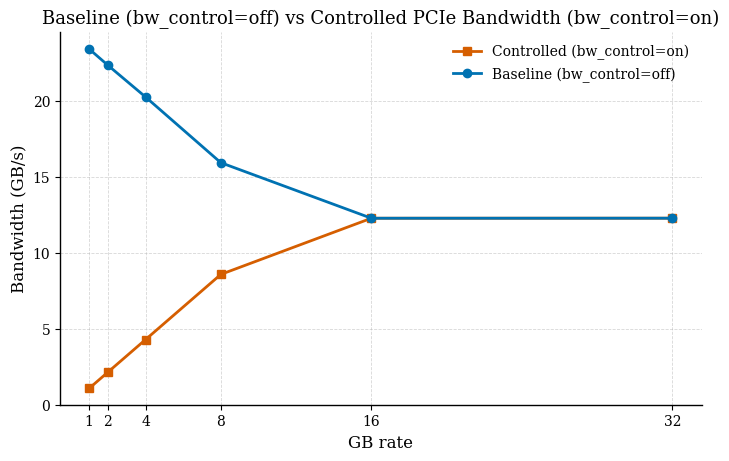

In [38]:
# Publication-style bandwidth comparison
style = {
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
}

legend_labels = {
    "bw_control=off": "Baseline (bw_control=off)",
    "bw_control=on": "Controlled (bw_control=on)",
}
colors = {"bw_control=off": "#0072B2", "bw_control=on": "#D55E00"}
markers = {"bw_control=off": "o", "bw_control=on": "s"}

with plt.rc_context(style):
    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)

    for label in df["label"].unique():
        series = df[df["label"] == label].sort_values("gb_rate")
        ax.plot(
            series["gb_rate"],
            series["bandwidth_GBps"],
            label=legend_labels.get(label, label),
            color=colors.get(label),
            marker=markers.get(label, "o"),
            linewidth=2,
            markersize=6,
        )

    ax.set(
        xlabel="GB rate",
        ylabel="Bandwidth (GB/s)",
        title="Baseline (bw_control=off) vs Controlled PCIe Bandwidth (bw_control=on)",
        xticks=sorted(df["gb_rate"].unique()),
    )
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()
    fig.savefig(f"../figures/{EXP_NAME}_baseline_vs_ctrl_bw_rate_{metadata['parameters']['worker_number']}_workers_bandwidth.png")

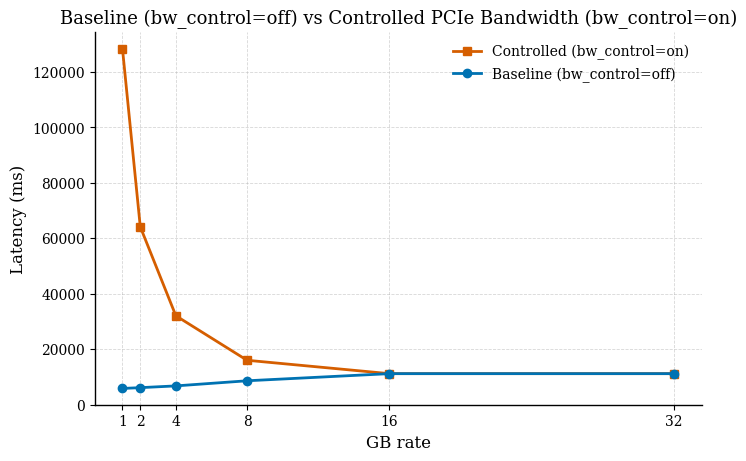

In [39]:
# Publication-style bandwidth comparison
style = {
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
}

legend_labels = {
    "bw_control=off": "Baseline (bw_control=off)",
    "bw_control=on": "Controlled (bw_control=on)",
}
colors = {"bw_control=off": "#0072B2", "bw_control=on": "#D55E00"}
markers = {"bw_control=off": "o", "bw_control=on": "s"}

with plt.rc_context(style):
    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)

    for label in df["label"].unique():
        series = df[df["label"] == label].sort_values("gb_rate")
        ax.plot(
            series["gb_rate"],
            series["latency_ms"],
            label=legend_labels.get(label, label),
            color=colors.get(label),
            marker=markers.get(label, "o"),
            linewidth=2,
            markersize=6,
        )

    ax.set(
        xlabel="GB rate",
        ylabel="Latency (ms)",
        title="Baseline (bw_control=off) vs Controlled PCIe Bandwidth (bw_control=on)",
        xticks=sorted(df["gb_rate"].unique()),
    )
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()
    fig.savefig(f"../figures/{EXP_NAME}_baseline_vs_ctrl_bw_rate_{metadata['parameters']['worker_number']}_workers_latency.png")

# 4 Workers (1 Baseline vs 3 Controlled)

In [27]:
# Work on Latest Exp, unless stated otherwise
EXP_PATH_PRE=EXP_RESULTS_PATH + EXP_NAME

latest_exp_dir = get_latest_experiment_dir(EXP_RESULTS_PATH, EXP_PATH_PRE, key='worker_number', value=[1,2,3,4])

if latest_exp_dir:
    print(f"Latest experiment directory: {latest_exp_dir}")
else:
    print("No matching experiment directory found.")

Latest experiment directory: ../results/../results/pcie_stress_baseline_vs_ctrl_bw_20261005T195405


In [28]:
# Print experiment metadata
with open(f"{latest_exp_dir}/{EXP_METADATA}", 'r') as f:
    metadata = json.load(f)
    print(json.dumps(metadata, indent=2))

{
  "experiment_name": "pcie_stress_baseline_vs_ctrl_bw",
  "git_commit": "a5ed878eb34cf7a3cd40d9fbf534291c736df61f",
  "parameters": {
    "baseline_workers": 1,
    "bw_control": [
      "on",
      "on",
      "on",
      "off"
    ],
    "controlled_workers": 3,
    "gb_rate": [
      1,
      2,
      4,
      8,
      16,
      32
    ],
    "worker_number": [
      1,
      2,
      3,
      4
    ]
  },
  "run_id": "pcie_stress_baseline_vs_ctrl_bw_20261005T195405",
  "timestamp": "20261005T195405"
}


In [30]:
df = pd.DataFrame()
for gb_rate in metadata['parameters']['gb_rate']:
    for worker_id in metadata['parameters']['worker_number']:
        if worker_id == len(metadata['parameters']['worker_number']):
            metrics_file = f"{latest_exp_dir}/gb_rate-{gb_rate}/{EXP_METRICS_PREFIX}-{worker_id}-bw_control=off.csv" # baseline is always the last worker
        else:
            metrics_file = f"{latest_exp_dir}/gb_rate-{gb_rate}/{EXP_METRICS_PREFIX}-{worker_id}-bw_control=on.csv"

        df_tmp = pd.read_csv(metrics_file)
        row = {
            'bytes_transferred': df_tmp['bytes_transferred'].median(),
            'bandwidth_GBps' : df_tmp['bandwidth_GBps'].median(),
            'gb_rate': gb_rate,
            'label': f"worker-{worker_id}-bw_control={'off' if worker_id == len(metadata['parameters']['worker_number']) else 'on'}",
            'latency_ms': df_tmp['latency_ms'].median()
        }

        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)


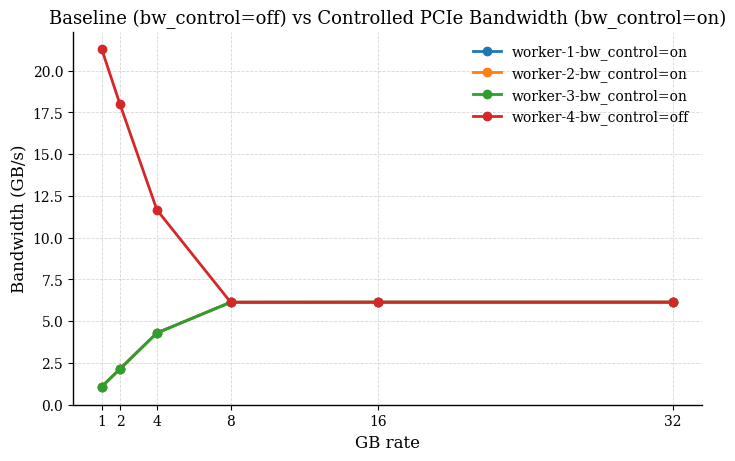

In [33]:
# Publication-style bandwidth comparison
style = {
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
}

legend_labels = {
    "bw_control=off": "Baseline (bw_control=off)",
    "bw_control=on": "Controlled (bw_control=on)",
}
colors = {"bw_control=off": "#0072B2", "bw_control=on": "#D55E00"}
markers = {"bw_control=off": "o", "bw_control=on": "s"}

with plt.rc_context(style):
    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)

    for label in df["label"].unique():
        series = df[df["label"] == label].sort_values("gb_rate")
        ax.plot(
            series["gb_rate"],
            series["bandwidth_GBps"],
            label=legend_labels.get(label, label),
            color=colors.get(label),
            marker=markers.get(label, "o"),
            linewidth=2,
            markersize=6,
        )

    ax.set(
        xlabel="GB rate",
        ylabel="Bandwidth (GB/s)",
        title="Baseline (bw_control=off) vs Controlled PCIe Bandwidth (bw_control=on)",
        xticks=sorted(df["gb_rate"].unique()),
    )
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()
    fig.savefig(f"../figures/{EXP_NAME}_baseline_vs_ctrl_bw_rate_{metadata['parameters']['worker_number']}_workers_bandwidth.png")

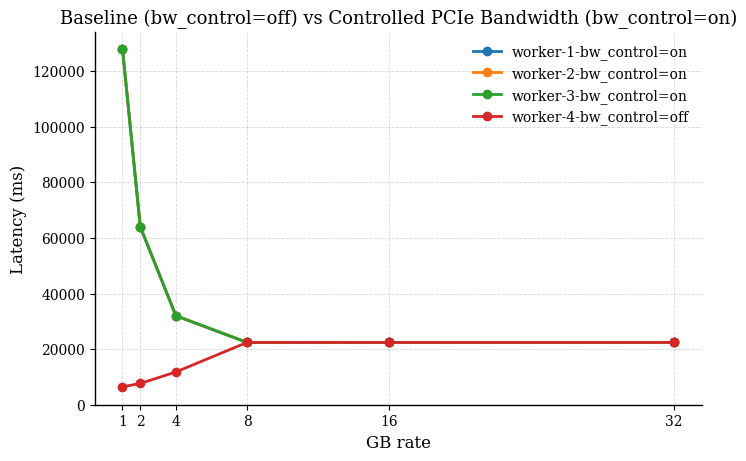

In [34]:
# Publication-style bandwidth comparison
style = {
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
}

legend_labels = {
    "bw_control=off": "Baseline (bw_control=off)",
    "bw_control=on": "Controlled (bw_control=on)",
}
colors = {"bw_control=off": "#0072B2", "bw_control=on": "#D55E00"}
markers = {"bw_control=off": "o", "bw_control=on": "s"}

with plt.rc_context(style):
    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)

    for label in df["label"].unique():
        series = df[df["label"] == label].sort_values("gb_rate")
        ax.plot(
            series["gb_rate"],
            series["latency_ms"],
            label=legend_labels.get(label, label),
            color=colors.get(label),
            marker=markers.get(label, "o"),
            linewidth=2,
            markersize=6,
        )

    ax.set(
        xlabel="GB rate",
        ylabel="Latency (ms)",
        title="Baseline (bw_control=off) vs Controlled PCIe Bandwidth (bw_control=on)",
        xticks=sorted(df["gb_rate"].unique()),
    )
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()
    fig.savefig(f"../figures/{EXP_NAME}_baseline_vs_ctrl_bw_rate_{metadata['parameters']['worker_number']}_workers_latency.png")